# WeGo Public Transit - Max Wallace

In [1]:
# import python modules and csv into a dataframe
import pandas as pd
import matplotlib.pyplot as plt

wego = pd.read_csv("../data/Headway Data, 8-1-2023 to 9-30-2023.csv")
wego.head()

,CALENDAR_ID,SERVICE_ABBR,ADHERENCE_ID,DATE,ROUTE_ABBR,BLOCK_ABBR,OPERATOR,TRIP_ID,OVERLOAD_ID,ROUTE_DIRECTION_NAME,...,ACTUAL_HDWY,HDWY_DEV,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT,STOP_CANCELLED,PREV_SCHED_STOP_CANCELLED,IS_RELIEF,DWELL_IN_MINS,SCHEDULED_LAYOVER_MINUTES
0,120230801,1,99457890,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,6.500000,NaN
1,120230801,1,99457891,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,0.000000,NaN
2,120230801,1,99457892,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,0.000000,NaN
3,120230801,1,99457893,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,NaN,0,0.000000,NaN
4,120230801,1,99457894,2023-08-01,22,2200,1040,345105,0,FROM DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,12.866666,5.0


In [2]:
# that's so many columns
wego.columns

Index(['CALENDAR_ID', 'SERVICE_ABBR', 'ADHERENCE_ID', 'DATE', 'ROUTE_ABBR',
       'BLOCK_ABBR', 'OPERATOR', 'TRIP_ID', 'OVERLOAD_ID',
       'ROUTE_DIRECTION_NAME', 'TIME_POINT_ABBR', 'ROUTE_STOP_SEQUENCE',
       'TRIP_EDGE', 'LATITUDE', 'LONGITUDE', 'SCHEDULED_TIME',
       'ACTUAL_ARRIVAL_TIME', 'ACTUAL_DEPARTURE_TIME', 'ADHERENCE',
       'SCHEDULED_HDWY', 'ACTUAL_HDWY', 'HDWY_DEV', 'ADJUSTED_EARLY_COUNT',
       'ADJUSTED_LATE_COUNT', 'ADJUSTED_ONTIME_COUNT', 'STOP_CANCELLED',
       'PREV_SCHED_STOP_CANCELLED', 'IS_RELIEF', 'DWELL_IN_MINS',
       'SCHEDULED_LAYOVER_MINUTES'],
      dtype='object')

### 1. What is the overall on-time performance, and what do the overall distribution of adherence look like?


On-Time: 79.7%
Late:    17.4%
Early:   2.9%

Min: -948.533333
Max: 88.383333 



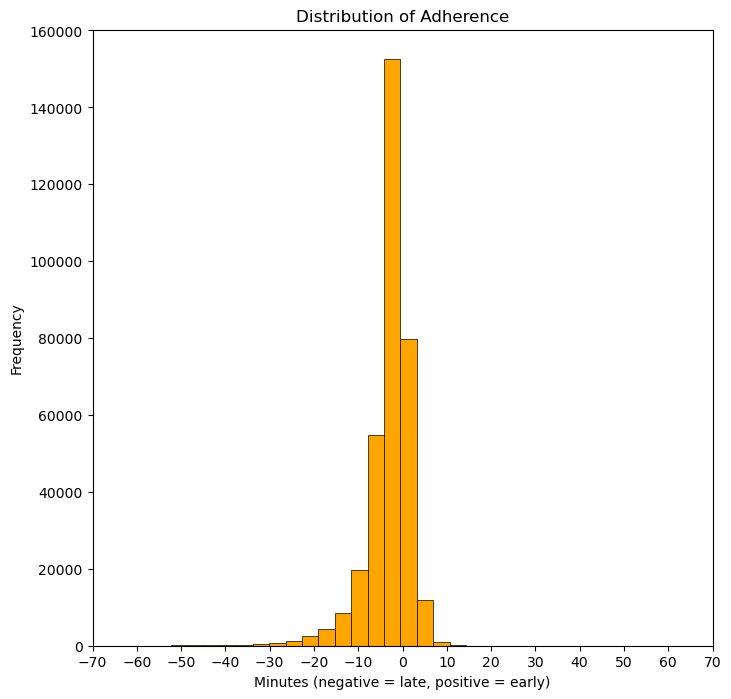

In [3]:
# overall on-time performance
total_late = wego['ADJUSTED_LATE_COUNT'].sum()
total_early = wego['ADJUSTED_EARLY_COUNT'].sum()
total_ontime = wego['ADJUSTED_ONTIME_COUNT'].sum()
total = total_late + total_early + total_ontime

print(f'\nOn-Time: {total_ontime / total * 100:.1f}%')
print(f'Late:    {total_late / total * 100:.1f}%')
print(f'Early:   {total_early / total * 100:.1f}%\n')

# rows with NaN adherence values filtered out
wego_adherence = wego.dropna(subset=['ADHERENCE']).sort_values(by='ADHERENCE', ascending=True)

#min/max adherence values
min_adh = wego_adherence['ADHERENCE'].min()
max_adh = wego_adherence['ADHERENCE'].max()
print('Min:',min_adh)
print('Max:', max_adh,'\n')

# plot distribution of adherence as a histogram (negative = late, positive = early)
wego_adherence['ADHERENCE'].plot(kind='hist', bins=280, figsize=(8, 8),xlim=(-70, 70), color='orange', edgecolor='black', linewidth=0.5)
plt.title('Distribution of Adherence')
plt.xlabel('Minutes (negative = late, positive = early)')
plt.xticks(range(-70, 71, 10))
plt.show()

### 2. How does direction of travel, route, or location affect the on-time performance?

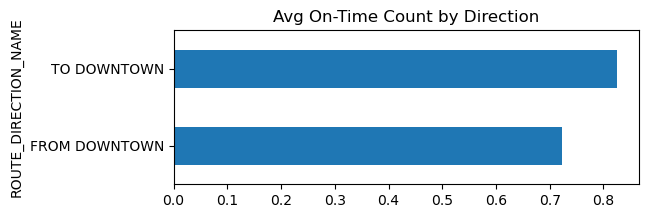

In [4]:
# on-time % by route direction using average 'ADJUSTED_ONTIME_COUNT' value
wego.groupby('ROUTE_DIRECTION_NAME')['ADJUSTED_ONTIME_COUNT'].mean().plot(kind='barh', figsize=(6, 2))
plt.title('Avg On-Time Count by Direction')
plt.show()

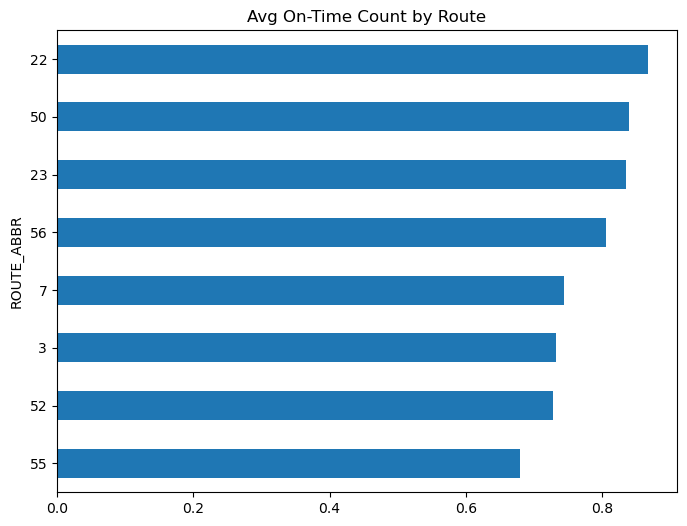

In [5]:
# on-time % by route
wego.groupby('ROUTE_ABBR')['ADJUSTED_ONTIME_COUNT'].mean().sort_values().plot(kind='barh', figsize=(8, 6))
plt.title('Avg On-Time Count by Route')
plt.show()

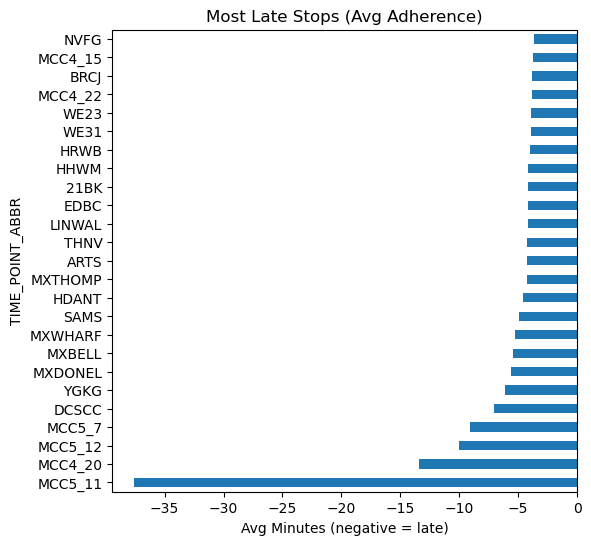

In [6]:
# average adherence by stop - bottom 15 worst
#filter for stops that are not cancelled
wego_active = wego[wego['STOP_CANCELLED'] == 0]

# plot bar
wego_active.groupby('TIME_POINT_ABBR')['ADHERENCE'].mean().sort_values().head(25).plot(kind='barh',figsize=(6,6))
plt.title('Most Late Stops (Avg Adherence)')
plt.xlabel('Avg Minutes (negative = late)')
plt.show()

In [7]:
pd.to_datetime(wego['SCHEDULED_TIME']).head()

0   2023-08-01 04:42:00
1   2023-08-01 04:46:00
2   2023-08-01 04:54:00
3   2023-08-01 05:10:00
4   2023-08-01 05:15:00
Name: SCHEDULED_TIME, dtype: datetime64[ns]

### 3. How does time of day or day of week affect on-time performance?

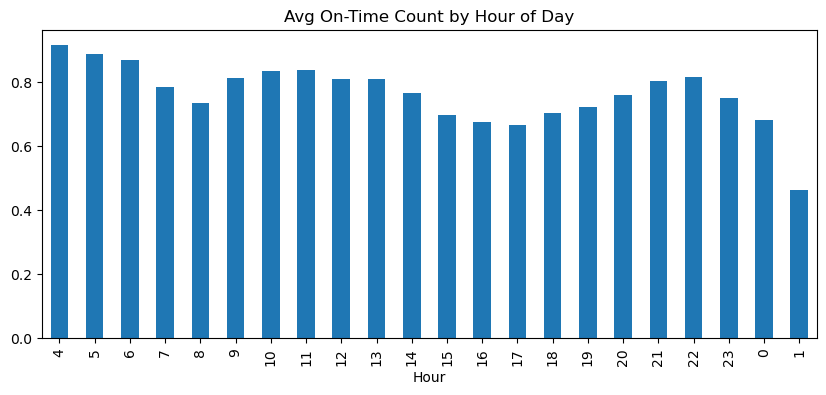

In [8]:
# convert column to datetime object and make hour column
wego['SCHEDULED_TIME'] = pd.to_datetime(wego['SCHEDULED_TIME'])
wego['hour'] = wego['SCHEDULED_TIME'].dt.hour

# new list for desired hour order on the x axis
# the new hour order better reflects the bus's actual shift
hour_order = list(range(4, 24)) + [0, 1]

# group by hour and reindex based on list we just made
wego.groupby('hour')['ADJUSTED_ONTIME_COUNT'].mean().reindex(hour_order).plot(kind='bar', figsize=(10, 4))
plt.title('Avg On-Time Count by Hour of Day')
plt.xlabel('Hour')
plt.xticks(range(len(hour_order)), hour_order)
plt.show()

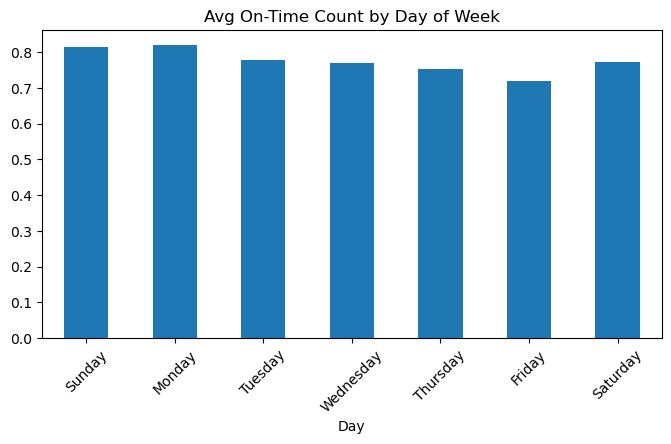

In [9]:
# on-time count by day of week
wego['DATE'] = pd.to_datetime(wego['DATE'])
wego['day_of_week'] = wego['DATE'].dt.day_name()

#desired day order
day_order = ['Sunday','Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

# plot mean on-time count for each day
wego.groupby('day_of_week')['ADJUSTED_ONTIME_COUNT'].mean().reindex(day_order).plot(kind='bar', figsize=(8, 4))
plt.title('Avg On-Time Count by Day of Week')
plt.xlabel('Day')
plt.xticks(rotation=45)
plt.show()

### 4. How much of a factor does the driver have on on-time performance? The driver is indicated by the OPERATOR variable.

In [10]:
# filter out relief stops (first crossing of a new driver doesn't reflect their performance)
wego_drivers = wego[wego['IS_RELIEF'] == 0]

# Calculate each operator's on-time percentage
operator_ontime = wego_drivers.groupby('OPERATOR')['ADJUSTED_ONTIME_COUNT'].mean() * 100

# How spread out are operators?
print(f"\nBest operator:  {operator_ontime.max():.1f}%")
print(f"Worst operator: {operator_ontime.min():.1f}%")
print(f"Average:        {operator_ontime.mean():.1f}%")
print(f"Std deviation:  {operator_ontime.std():.1f}%\n")


Best operator:  100.0%
Worst operator: 0.0%
Average:        73.9%
Std deviation:  16.2%



In [11]:
operator_ontime.sort_values(ascending=True)

OPERATOR
656       0.000000
473       0.000000
2982      6.060606
1016     17.288136
1377     20.000000
           ...    
2639     97.115385
1706     97.619048
1597     97.674419
2294    100.000000
56      100.000000
Name: ADJUSTED_ONTIME_COUNT, Length: 340, dtype: float64

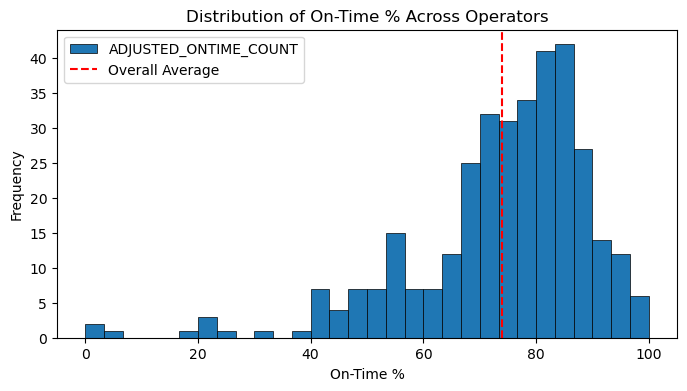

In [12]:
# Distribution of on-time % across operators
operator_ontime.plot(kind='hist', bins=30, edgecolor='black', linewidth=0.5, figsize=(8, 4))
plt.axvline(operator_ontime.mean(), color='red', linestyle='--', label='Overall Average')
plt.title('Distribution of On-Time % Across Operators')
plt.xlabel('On-Time %')
plt.legend()
plt.show()

### 5. Is there any relationship between lateness (ADHERENCE) and headway deviation? The headway deviation variable is contained in the HDWY_DEV column. See the notes under number 9 for a description of headway and headway deviation.

C:\Users\BolognaColonel\AppData\Local\Temp\ipykernel_14332\1129651890.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wego_hdwy['hdwy_dev_pct'] = wego_hdwy['HDWY_DEV'] / wego_hdwy['SCHEDULED_HDWY'] * 100


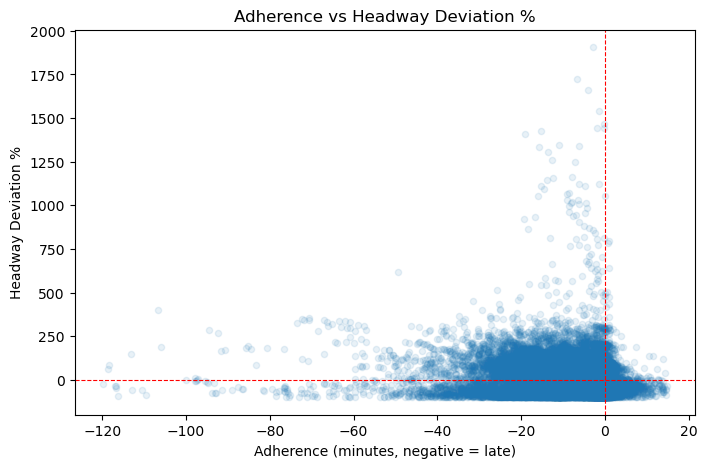

In [13]:
# new dataframe filtering for rows where stops aren't cancelled
wego_hdwy = wego[(wego['STOP_CANCELLED'] == 0) & (wego['PREV_SCHED_STOP_CANCELLED'] == 0)]

# calculate headway deviation percentage
wego_hdwy['hdwy_dev_pct'] = wego_hdwy['HDWY_DEV'] / wego_hdwy['SCHEDULED_HDWY'] * 100

# clip to reasonable ranges to remove outliers
plot_data = wego_hdwy[(wego_hdwy['ADHERENCE'].between(-120, 15)) & (wego_hdwy['hdwy_dev_pct'].between(-200, 2000))]

# scatter plot of adherence vs headway deviation %
plot_data.plot.scatter(x='ADHERENCE', y='hdwy_dev_pct', alpha=0.1, figsize=(8, 5))
plt.title('Adherence vs Headway Deviation %')
plt.xlabel('Adherence (minutes, negative = late)')
plt.ylabel('Headway Deviation %')
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.axvline(0, color='red', linestyle='--', linewidth=0.8)
plt.show()

In [14]:
# correlation between headway deviation % and adherence
print(wego_hdwy[['ADHERENCE', 'hdwy_dev_pct']].corr())

              ADHERENCE  hdwy_dev_pct
ADHERENCE      1.000000     -0.219007
hdwy_dev_pct  -0.219007      1.000000


### 6. How much impact does being late or too spaced out at the first stop have downstream?

C:\Users\BolognaColonel\AppData\Local\Temp\ipykernel_14332\1317141898.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  downstream.groupby('first_stop_bin')['ADHERENCE'].mean().mul(-1).plot(kind='bar')


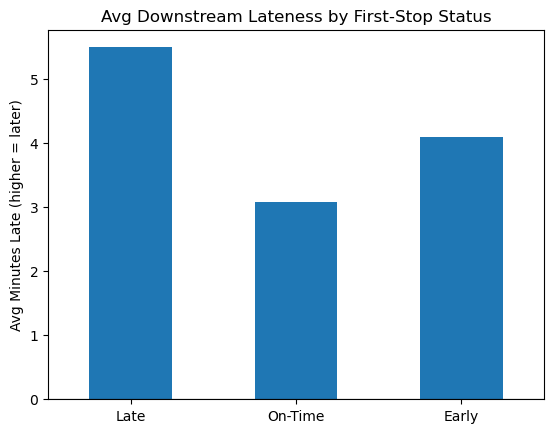

In [15]:
# get first stop of each trip
first_stops = wego[wego['TRIP_EDGE'] == 1][['TRIP_ID', 'ADHERENCE']].rename(columns={'ADHERENCE': 'first_stop_adherence'})

# get all non-first stops
downstream = wego[wego['TRIP_EDGE'] != 1].merge(first_stops, on='TRIP_ID')

# bin first-stop adherence and plot downstream adherence
downstream['first_stop_bin'] = pd.cut(downstream['first_stop_adherence'], bins=[-60, -6, 1, 60], labels=['Late', 'On-Time', 'Early'])

downstream.groupby('first_stop_bin')['ADHERENCE'].mean().mul(-1).plot(kind='bar')
plt.title('Avg Downstream Lateness by First-Stop Status')
plt.ylabel('Avg Minutes Late (higher = later)')
plt.xlabel('')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=0)
plt.show()

### 7. What is the impact of the layover at the start of the trip (the difference between the first stop arrival and departure time)? Does more dwell time at the beginning of a trip lead to more stable headways (lower values for % headway deviation)? Do trips with longer scheduled layover time have more stable headway values?

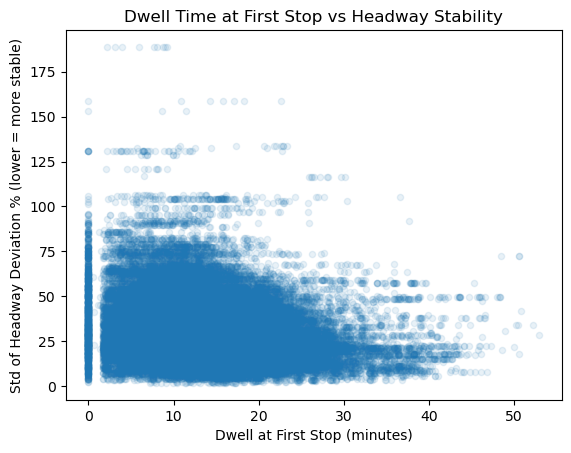

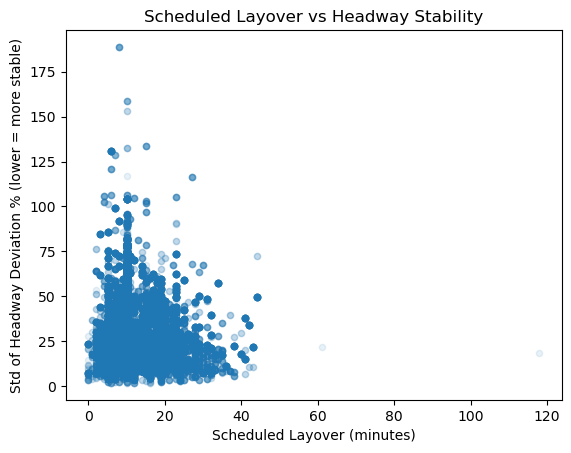

                           DWELL_IN_MINS  SCHEDULED_LAYOVER_MINUTES  hdwy_std
DWELL_IN_MINS                   1.000000                   0.683505 -0.188297
SCHEDULED_LAYOVER_MINUTES       0.683505                   1.000000 -0.117676
hdwy_std                       -0.188297                  -0.117676  1.000000


In [16]:
# Get trip-level first stop dwell and layover
trip_starts = wego[wego['TRIP_EDGE'] == 1][['TRIP_ID', 'DWELL_IN_MINS', 'SCHEDULED_LAYOVER_MINUTES']]

# Compute per-trip headway deviation std as a stability measure
hdwy_stability = wego_hdwy.groupby('TRIP_ID')['hdwy_dev_pct'].std().reset_index()
hdwy_stability.columns = ['TRIP_ID', 'hdwy_std']

trip_analysis = trip_starts.merge(hdwy_stability, on='TRIP_ID').dropna()

# Clip outliers to meaningful ranges
trip_analysis = trip_analysis[
    (trip_analysis['DWELL_IN_MINS'].between(0, 60)) &
    (trip_analysis['hdwy_std'] < 200)
]

# Scatter: dwell time vs headway stability
trip_analysis.plot.scatter(x='DWELL_IN_MINS', y='hdwy_std', alpha=0.1)
plt.title('Dwell Time at First Stop vs Headway Stability')
plt.xlabel('Dwell at First Stop (minutes)')
plt.ylabel('Std of Headway Deviation % (lower = more stable)')
plt.show()

# Scatter: scheduled layover vs headway stability
trip_analysis.plot.scatter(x='SCHEDULED_LAYOVER_MINUTES', y='hdwy_std', alpha=0.1)
plt.title('Scheduled Layover vs Headway Stability')
plt.xlabel('Scheduled Layover (minutes)')
plt.ylabel('Std of Headway Deviation % (lower = more stable)')
plt.show()

print(trip_analysis[['DWELL_IN_MINS', 'SCHEDULED_LAYOVER_MINUTES', 'hdwy_std']].corr())

### 8. What is the relationship between distance or time traveled since the start of a given trip and the adherence value? Does on-time performance become less stable the further along the route the bus has traveled?

C:\Users\BolognaColonel\AppData\Local\Temp\ipykernel_14332\3513465503.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wego.groupby('stop_bin')['ADHERENCE'].std().plot(kind='bar', figsize=(10, 4))


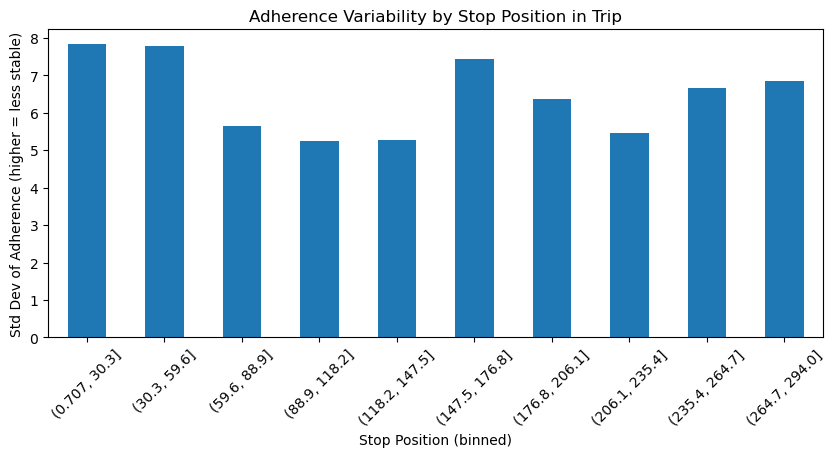

In [17]:
# Use stop_rank as a proxy for progress (or calculate elapsed stops per trip)
wego['stop_rank'] = wego.groupby('TRIP_ID').cumcount() + 1

# Bin by stop rank
wego['stop_bin'] = pd.cut(wego['stop_rank'], bins=10)
wego.groupby('stop_bin')['ADHERENCE'].std().plot(kind='bar', figsize=(10, 4))
plt.title('Adherence Variability by Stop Position in Trip')
plt.xlabel('Stop Position (binned)')
plt.ylabel('Std Dev of Adherence (higher = less stable)')
plt.xticks(rotation=45)
plt.show()

### 9. Headway is the amount of time between a bus and the prior bus at the same stop. In the dataset, the amount of headway scheduled is contained in the SCHEDULED_HDWY column and indicates the difference between the scheduled time for a particular stop and the scheduled time for the previous bus on that same stop. This dataset contains a column HDWY_DEV, which shows the amount of deviation from the scheduled headway. Bunching occurs when there is shorter headway than scheduled, which would appear as a negative HDWY_DEV value. Gapping is when there is more headway than scheduled and appears as a positive value in the HDWY_DEV column. Note that you can calculate headway deviation percentage as HDWY_DEV/SCHEDULED_HDWY. The generally accepted range of headway deviation is 50% to 150% of the scheduled headway, so if scheduled headway is 10 minutes, a headway deviation of up to 5 minutes would be acceptable (but not ideal). How do the variables studied related to headway deviation?

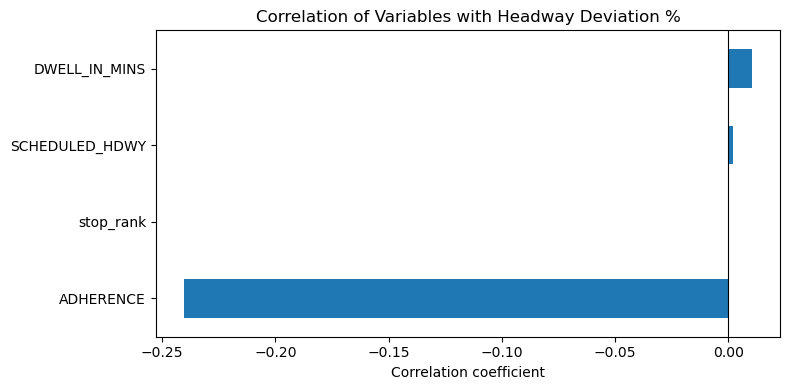

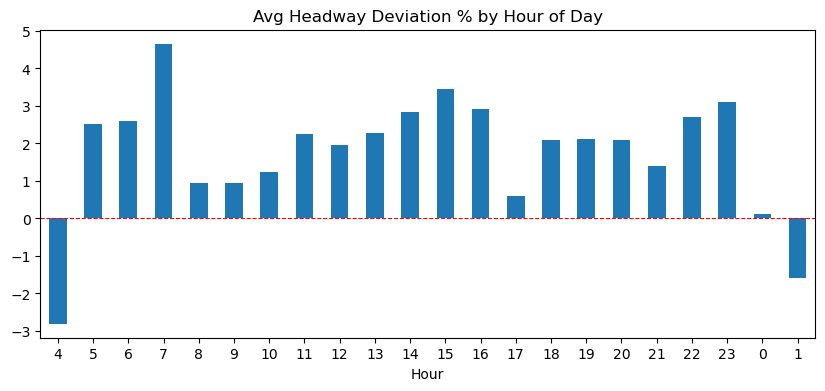

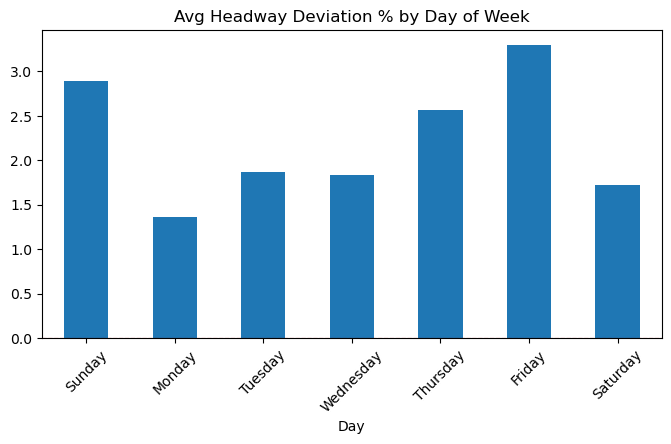

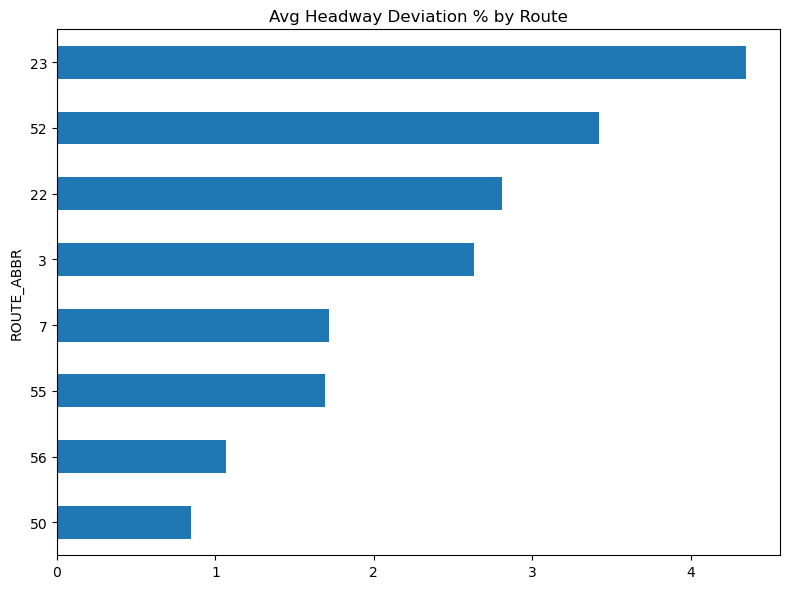

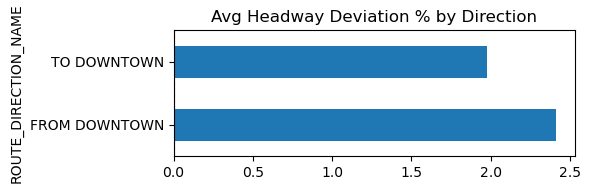

In [18]:
# Make sure hdwy_dev_pct exists (from #5)
wego_hdwy = wego[(wego['STOP_CANCELLED'] == 0) & (wego['PREV_SCHED_STOP_CANCELLED'] == 0)].copy()
wego_hdwy['hdwy_dev_pct'] = wego_hdwy['HDWY_DEV'] / wego_hdwy['SCHEDULED_HDWY'] * 100

# add stop_rank if not already on wego
wego_hdwy['stop_rank'] = wego_hdwy.groupby('TRIP_ID').cumcount() + 1

# clip outliers
wego_hdwy = wego_hdwy[wego_hdwy['hdwy_dev_pct'].between(-200, 300)]


# Plots! Lots!
# correlation of numeric variables with hdwy_dev_pct
numeric_vars = ['ADHERENCE', 'stop_rank', 'DWELL_IN_MINS', 'SCHEDULED_HDWY']
corr_table = wego_hdwy[numeric_vars + ['hdwy_dev_pct']].corr()['hdwy_dev_pct'].drop('hdwy_dev_pct').sort_values()

corr_table.plot(kind='barh', figsize=(8, 4))
plt.title('Correlation of Variables with Headway Deviation %')
plt.xlabel('Correlation coefficient')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# avg headway deviation % by hour
wego_hdwy.groupby('hour')['hdwy_dev_pct'].mean().reindex(hour_order).plot(kind='bar', figsize=(10, 4))
plt.title('Avg Headway Deviation % by Hour of Day')
plt.xlabel('Hour')
plt.xticks(range(len(hour_order)), hour_order, rotation=0)
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.show()

# avg headway deviation % by day of week
wego_hdwy.groupby('day_of_week')['hdwy_dev_pct'].mean().reindex(day_order).plot(kind='bar', figsize=(8, 4))
plt.title('Avg Headway Deviation % by Day of Week')
plt.xlabel('Day')
plt.xticks(rotation=45)
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.show()

# avg headway deviation % by route
wego_hdwy.groupby('ROUTE_ABBR')['hdwy_dev_pct'].mean().sort_values().plot(kind='barh', figsize=(8, 6))
plt.title('Avg Headway Deviation % by Route')
plt.axvline(0, color='red', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

# avg headway deviation % by direction
wego_hdwy.groupby('ROUTE_DIRECTION_NAME')['hdwy_dev_pct'].mean().plot(kind='barh', figsize=(6, 2))
plt.title('Avg Headway Deviation % by Direction')
plt.axvline(0, color='red', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()